# **Deep Learning Assigment - 4**
## Name: Anumalasetty Sohan Kumar
## Roll No.: CS23B1004

## Name: Shishir Kumar Reddy Ambala
## Roll No.: CS23B2043
---

# Deepfake Detection using ResNet-34 and ResNet-152

## 1. Objective

The objective of this assignment is to develop a deep learning model capable of detecting deepfake images using convolutional neural networks. The study focuses on implementing and evaluating two architectures: a manually implemented ResNet-34 model and a pretrained ResNet-152 model. The goal is to understand the effectiveness of deep residual networks in identifying manipulated media.

---

## 2. Problem Statement

Deepfakes are synthetic media generated using deep learning techniques that manipulate facial expressions and identities in images or videos. These manipulated contents pose significant risks in areas such as misinformation, identity theft, and digital security. Therefore, robust deepfake detection systems are required to distinguish between real and fake media.

This assignment aims to classify images into two categories:
- **Real**
- **Fake (Deepfake)**

---

## 3. Dataset Description

The dataset used in this assignment consists of images labeled as real or fake along with metadata that contains information about the image files. The dataset is provided through Google Drive links and contains images extracted from deepfake datasets.

### Dataset Components

- Image files used for training and testing
- Metadata file containing labels and image information

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        pass

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Library Imports and Environment Setup

Random seeds are set to ensure reproducibility of results across runs. The code also detects whether a GPU is available and selects the appropriate device (`cuda` or `cpu`) for model training.

In [2]:
import os, random, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Dataset Loading and Metadata Inspection

This cell defines the dataset directory and loads the metadata files for the **FFPP** and **CelebDF** datasets using pandas. It then prints the column names and displays a few sample rows from each metadata file to understand the structure of the dataset and identify the relevant fields required for the deepfake classification task.

In [3]:
INPUT_DIR    = '/kaggle/input/datasets/sohanuuu/deepfake-detection'
EXTRACT_DIR  = '/kaggle/input/datasets/sohanuuu/deepfake-detection'
SAVE_DIR     = '/kaggle/working'
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
IMG_SIZE    = 224
BATCH_SIZE  = 32        
NUM_WORKERS = 2       
WEIGHT_DECAY = 1e-4

# ImageNet normalization constants
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

print('Config ready.')

Config ready.


In [5]:
ffpp_meta  = pd.read_csv(os.path.join(INPUT_DIR, 'FFPP_metadata.csv'))
celeb_meta = pd.read_csv(os.path.join(INPUT_DIR, 'CelebDF_metadata.csv'))

print('FFPP  columns:', ffpp_meta.columns.tolist())
print('CelebDF columns:', celeb_meta.columns.tolist())
print()
print('FFPP sample:')
display(ffpp_meta.head(3))
print('CelebDF sample:')
display(celeb_meta.head(3))

FFPP  columns: ['image_path', 'label', 'dataset', 'manipulation_type', 'video_id']
CelebDF columns: ['image_path', 'label', 'dataset', 'manipulation_type', 'video_id']

FFPP sample:


,image_path,label,dataset,manipulation_type,video_id
0,FFPP/train/real/real_776_0.jpg,0,FFPP,real,776
1,FFPP/train/real/real_776_1.jpg,0,FFPP,real,776
2,FFPP/train/real/real_776_2.jpg,0,FFPP,real,776


CelebDF sample:


,image_path,label,dataset,manipulation_type,video_id
0,CelebDF/train/fake/id17_id26_0005_0.jpg,1,CelebDF,fake,id17_id26_0005
1,CelebDF/train/fake/id17_id26_0005_1.jpg,1,CelebDF,fake,id17_id26_0005
2,CelebDF/train/fake/id17_id26_0005_2.jpg,1,CelebDF,fake,id17_id26_0005


### Relevant Columns Used

From the metadata file, only the relevant columns required for classification are used:

- **image_path** – Name of the image file
- **label** – Indicates whether the image is real or fake

In [6]:
ffpp_meta  = ffpp_meta [['image_path', 'label']]
celeb_meta = celeb_meta[['image_path', 'label']]

all_meta          = pd.concat([ffpp_meta, celeb_meta], ignore_index=True)
all_meta['label'] = all_meta['label'].astype(int)

def detect_split(path):
    for part in path.replace('\\\\', '/').split('/'):
        if part in ('train', 'val', 'test'):
            return part
    return 'train'

all_meta['split'] = all_meta['image_path'].apply(detect_split)

print(f'Total samples : {len(all_meta):,}')
print()
print(all_meta.groupby(['split','label']).size()
              .rename('count').reset_index()
              .replace({0:'real', 1:'fake'}).to_string(index=False))

Total samples : 100,198

split label  count
 test  real   2621
 test  fake   8720
train  real  10492
train  fake  63952
  val  real   1992
  val  fake  12421


In [7]:
train_df = all_meta[all_meta['split']=='train'][['image_path','label']].reset_index(drop=True)
val_df   = all_meta[all_meta['split']=='val'  ][['image_path','label']].reset_index(drop=True)
test_df  = all_meta[all_meta['split']=='test' ][['image_path','label']].reset_index(drop=True)

# Carve 10% val from train if no val split in metadata
if len(val_df) == 0:
    train_df, val_df = train_test_split(
        train_df, test_size=0.1, stratify=train_df['label'], random_state=SEED
    )
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    print('\nNo val split found — carved 10% from train.')

print(f'\nTrain : {len(train_df):>6,}')
print(f'Val   : {len(val_df):>6,}')
print(f'Test  : {len(test_df):>6,}')


Train : 74,444
Val   : 14,413
Test  : 11,341


## Custom Dataset and Data Preparation

This section defines a custom **DeepfakeDataset** class to load images and labels for the deepfake detection task. The dataset reads image paths and labels from the metadata, constructs the correct file path on disk, and loads each image using PIL. If an image cannot be loaded, a blank placeholder image is used to prevent training interruptions.

Data preprocessing and augmentation techniques are applied using torchvision transforms. Training data uses augmentation such as random cropping, horizontal flipping, and color jitter to improve model generalization, while validation and test data use only resizing and normalization.

Finally, PyTorch **DataLoaders** are created for the training, validation, and test datasets with the specified batch size and number of workers, enabling efficient batch processing during model training and evaluation.

In [8]:
class DeepfakeDataset(Dataset):
    def __init__(self, df, data_root, transform=None):
        self.data      = df[['image_path','label']].reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        label = int(row['label'])
        parts     = row['image_path'].split('/')
        fixed     = parts[0] + '/' + '/'.join(parts)   # duplicate root prefix
        full_path = os.path.join(self.data_root, fixed)
        try:
            img = Image.open(full_path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform:
            img = self.transform(img)
        return img, label


train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = DeepfakeDataset(train_df, EXTRACT_DIR, train_tf)
val_ds   = DeepfakeDataset(val_df,   EXTRACT_DIR, val_test_tf)
test_ds  = DeepfakeDataset(test_df,  EXTRACT_DIR, val_test_tf)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

imgs, labels = next(iter(train_loader))
print(f'Batch shape : {imgs.shape}')
print(f'Label dist  : {labels.bincount().tolist()}  (index 0=real, 1=fake)')

Batch shape : torch.Size([32, 3, 224, 224])
Label dist  : [6, 26]  (index 0=real, 1=fake)


## Data Visualization

This cell visualizes a batch of training images from the DataLoader to verify that the dataset and preprocessing pipeline are working correctly. The images are first **denormalized** to restore their original color values for proper visualization. 

A grid of sample images is displayed with their corresponding labels, where **green indicates real images** and **red indicates fake images**. The visualization helps confirm that images are being loaded, transformed, and labeled correctly before training the model.

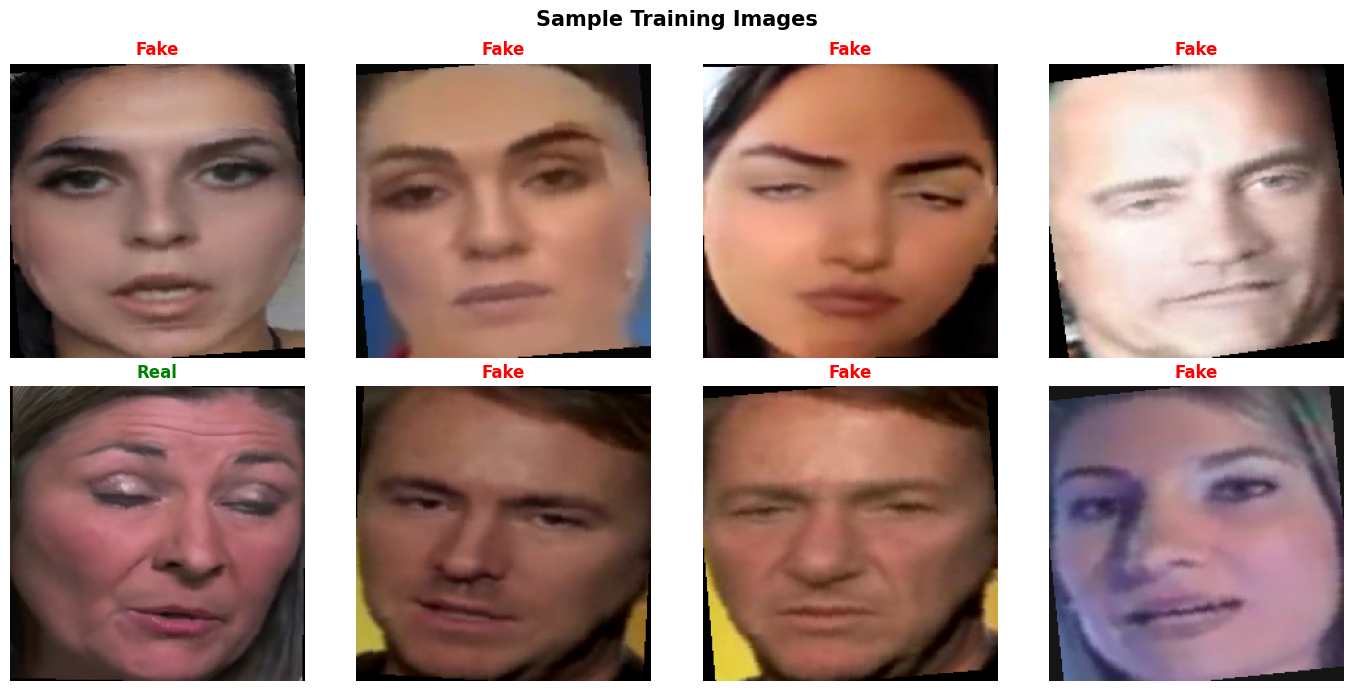

In [9]:
def denorm(t):
    img = t.cpu().numpy().transpose(1,2,0)
    img = np.array(STD)*img + np.array(MEAN)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
label_name = {0:'Real', 1:'Fake'}
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(imgs[i]))
    lbl = labels[i].item()
    ax.set_title(label_name[lbl], fontsize=12,
                 color='green' if lbl==0 else 'red', fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## Model Architecture - **pretrained ResNet-152**

The model is initialized with **ImageNet weights**, allowing it to leverage strong pretrained visual features.

To reduce training time and prevent overfitting, the **entire backbone is frozen** and only a **lightweight classification head** is trained.

### Custom Classification Head
The original fully connected layer is replaced with:

- Batch Normalization
- Dropout for regularization
- A compact hidden layer
- Final binary classifier (**Real vs Fake**)

This design keeps the number of trainable parameters **very small (<2M)**, enabling **fast training within limited time budgets**.

In [10]:
def build_model(dropout=0.4):
    """
    ResNet-152 with frozen backbone + lightweight 2-class head.
    The head alone has < 2 M parameters — training it takes seconds per epoch.
    """
    base = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

    # Freeze ALL backbone weights
    for p in base.parameters():
        p.requires_grad = False

    # Replace FC with a slim binary-classification head
    in_f = base.fc.in_features          # 2048 for ResNet-152
    base.fc = nn.Sequential(
        nn.BatchNorm1d(in_f),
        nn.Dropout(p=dropout),
        nn.Linear(in_f, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=dropout/2),
        nn.Linear(256, 2),
    )
    return base

model = build_model().to(DEVICE)
print('Model built and moved to', DEVICE)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 192MB/s]  


Model built and moved to cuda


In [11]:
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('='*60)
print(f'  ResNet-152  —  Parameter Count')
print('='*60)
print(f'  Total parameters     : {total:>15,}')
print(f'  Trainable parameters : {trainable:>15,}')
print(f'  Frozen parameters    : {total-trainable:>15,}')
print(f'  Trainable ratio      : {100*trainable/total:>14.2f} %')
print('='*60)

print()
print(f'  {"Block":<18}  {"# Params":>12}  {"Status":>10}')
print('-'*50)
for name, module in model.named_children():
    p = sum(x.numel() for x in module.parameters())
    t = sum(x.numel() for x in module.parameters() if x.requires_grad)
    status = 'Trainable' if t > 0 else 'Frozen'
    print(f'  {name:<18}  {p:>12,}  {status:>10}')

print()
print('Custom FC head architecture:')
print(model.fc)

  ResNet-152  —  Parameter Count
  Total parameters     :      58,672,962
  Trainable parameters :         529,154
  Frozen parameters    :      58,143,808
  Trainable ratio      :           0.90 %

  Block                   # Params      Status
--------------------------------------------------
  conv1                      9,408      Frozen
  bn1                          128      Frozen
  relu                           0      Frozen
  maxpool                        0      Frozen
  layer1                   215,808      Frozen
  layer2                 2,339,840      Frozen
  layer3                40,613,888      Frozen
  layer4                14,964,736      Frozen
  avgpool                        0      Frozen
  fc                       529,154   Trainable

Custom FC head architecture:
Sequential(
  (0): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (1): Dropout(p=0.4, inplace=False)
  (2): Linear(in_features=2048, out_features=256, bias=True)
  (3

## Progressive Fine-Tuning Strategy

To efficiently adapt the pretrained network, we use **selective unfreezing**.

Instead of training the entire model at once, we gradually allow deeper layers to learn.

### Strategy
1. **Phase 1**
   - Only the **classification head (FC layer)** is trained.
   - Backbone remains frozen.

2. **Phase 2**
   - The **final convolutional block (layer4)** is unfrozen.
   - Allows the model to adapt high-level features to the deepfake task.

This approach stabilizes training and improves convergence when working with **limited training time**.

In [17]:
def freeze_backbone(m):
    for name, p in m.named_parameters():
        p.requires_grad = ('fc' in name)

def unfreeze_layer4(m):
    """Unfreeze layer4 + fc — the minimal extra set that boosts accuracy fastest."""
    freeze_backbone(m)
    for p in m.layer4.parameters():
        p.requires_grad = True

def unfreeze_layer3(m):
    freeze_backbone(m)
    for p in m.layer4.parameters():
        p.requires_grad = True
    for p in m.layer3.parameters():
        p.requires_grad = True

# Training loop
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n

# Evaluation loop
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_labels, all_probs  = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
        probs = torch.softmax(logits, 1)[:, 1]
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return total_loss/n, correct/n, np.array(all_labels), np.array(all_probs)

print('Helper functions defined.')

Helper functions defined.


## Handling Class Imbalance

Deepfake datasets often contain **uneven numbers of real and fake images**.

To compensate for this imbalance, we compute **class weights** based on the training distribution and apply them in the **CrossEntropyLoss** function.

In [13]:
counts  = train_df['label'].value_counts().sort_index()
weights = torch.tensor(
    [len(train_df) / (2.0 * counts[i]) for i in range(2)],
    dtype=torch.float
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
print(f'Class weights — real: {weights[0]:.4f}  |  fake: {weights[1]:.4f}')

Class weights — real: 3.5477  |  fake: 0.5820


---

## Experiment 1 — Adam Optimizer

The first experiment trains the model using the **Adam optimizer**.

### Configuration
- Optimizer: Adam
- Learning Rate:
  - Phase 1 (FC only): `1e-3`
  - Phase 2 (FC + Layer4): `2e-4`
- Epochs: 10 (5 + 5)
- Scheduler: Cosine Annealing
- Dropout: 0.4

### Additional Techniques
- Cosine learning rate scheduling
- Gradient clipping
- Progress bar monitoring with `tqdm`

The model with the **best validation AUC** is saved during training.

In [16]:
EXP1_NAME = 'Adam'
EXP1_SAVE = os.path.join(SAVE_DIR, 'resnet152_adam_best.pth')

model_adam = build_model(dropout=0.4).to(DEVICE)
history_adam = dict(train_loss=[], train_acc=[], val_loss=[], val_acc=[], val_auc=[], lr=[], phase=[])

best_auc_adam = 0.0
t0 = time.time()

PHASES_ADAM = [
    ('Phase-1 FC only',   freeze_backbone, 5, 1e-3),
    ('Phase-2 FC+layer4', unfreeze_layer4, 5, 2e-4),
]

for phase_label, unfreeze_fn, n_epochs, lr in PHASES_ADAM:
    unfreeze_fn(model_adam)
    trainable = sum(p.numel() for p in model_adam.parameters() if p.requires_grad)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model_adam.parameters()),
        lr=lr, weight_decay=WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-7)

    print(f'\n{"="*65}')
    print(f'  Adam | {phase_label}  |  trainable params = {trainable:,}')
    print(f'{"="*65}')

    for ep in range(1, n_epochs + 1):
        cur_lr = optimizer.param_groups[0]['lr']

        # ── Train with progress bar ──────────────────────────
        model_adam.train()
        tr_loss_sum, tr_correct, tr_n = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f'  Ep {ep:02d}/{n_epochs} [train]', leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model_adam(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model_adam.parameters(), 1.0)
            optimizer.step()
            tr_loss_sum += loss.item() * imgs.size(0)
            tr_correct  += (logits.argmax(1) == labels).sum().item()
            tr_n        += imgs.size(0)
            pbar.set_postfix(loss=f'{tr_loss_sum/tr_n:.4f}', acc=f'{tr_correct/tr_n:.4f}')
        tr_loss, tr_acc = tr_loss_sum / tr_n, tr_correct / tr_n

        # ── Validate with progress bar ───────────────────────
        model_adam.eval()
        vl_loss_sum, vl_correct, vl_n = 0.0, 0, 0
        all_lbls, all_probs = [], []
        with torch.no_grad():
            pbar = tqdm(val_loader, desc=f'  Ep {ep:02d}/{n_epochs} [val]  ', leave=False)
            for imgs, labels in pbar:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = model_adam(imgs)
                loss   = criterion(logits, labels)
                vl_loss_sum += loss.item() * imgs.size(0)
                vl_correct  += (logits.argmax(1) == labels).sum().item()
                vl_n        += imgs.size(0)
                probs = torch.softmax(logits, 1)[:, 1]
                all_lbls.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                pbar.set_postfix(loss=f'{vl_loss_sum/vl_n:.4f}', acc=f'{vl_correct/vl_n:.4f}')
        vl_loss, vl_acc = vl_loss_sum / vl_n, vl_correct / vl_n
        vl_auc = roc_auc_score(all_lbls, all_probs)

        scheduler.step()
        torch.cuda.empty_cache()

        for k, v in zip(['train_loss','train_acc','val_loss','val_acc','val_auc','lr','phase'],
                        [tr_loss, tr_acc, vl_loss, vl_acc, vl_auc, cur_lr, phase_label]):
            history_adam[k].append(v)

        flag = ''
        if vl_auc > best_auc_adam:
            best_auc_adam = vl_auc
            torch.save(model_adam.state_dict(), EXP1_SAVE)
            flag = '  ← best'

        print(f'  Ep {ep:02d}/{n_epochs}  TrLoss {tr_loss:.4f}  TrAcc {tr_acc:.4f}  |  '
              f'VlLoss {vl_loss:.4f}  VlAcc {vl_acc:.4f}  VlAUC {vl_auc:.4f}  LR {cur_lr:.1e}{flag}')

elapsed = time.time() - t0
print(f'\n✓ Adam training done in {elapsed/60:.1f} min  |  Best val AUC = {best_auc_adam:.4f}')


  Adam | Phase-1 FC only  |  trainable params = 529,154


  Ep 01/5  TrLoss 0.6557  TrAcc 0.6436  |  VlLoss 0.6087  VlAcc 0.6558  VlAUC 0.7382  LR 1.0e-03  ← best


  Ep 02/5  TrLoss 0.6290  TrAcc 0.6728  |  VlLoss 0.6123  VlAcc 0.6482  VlAUC 0.7385  LR 9.0e-04  ← best


  Ep 03/5  TrLoss 0.6118  TrAcc 0.6879  |  VlLoss 0.6689  VlAcc 0.5678  VlAUC 0.7562  LR 6.5e-04  ← best


  Ep 04/5  TrLoss 0.6023  TrAcc 0.6988  |  VlLoss 0.6112  VlAcc 0.6530  VlAUC 0.7613  LR 3.5e-04  ← best


...

  Ep 01/5  TrLoss 0.4897  TrAcc 0.7875  |  VlLoss 0.3753  VlAcc 0.8383  VlAUC 0.8935  LR 2.0e-04  ← best


  Ep 02/5  TrLoss 0.3845  TrAcc 0.8503  |  VlLoss 0.3617  VlAcc 0.8521  VlAUC 0.9195  LR 1.8e-04  ← best


  Ep 03/5  TrLoss 0.3304  TrAcc 0.8785  |  VlLoss 0.3403  VlAcc 0.8599  VlAUC 0.9372  LR 1.3e-04  ← best


  Ep 04/5  TrLoss 0.2852  TrAcc 0.9036  |  VlLoss 0.3396  VlAcc 0.8691  VlAUC 0.9439  LR 6.9e-05  ← best


  Ep 05/5  TrLoss 0.2510  TrAcc 0.9153  |  VlLoss 0.3023  VlAcc 0.8928  VlAUC 0.9507  LR 1.9e-05  ← best

✓ Adam training done in 123.8 min  |  Best val AUC = 0.9507


**Observations**
- Validation loss decreased significantly after epoch 5 when **layer4 was unfrozen**, indicating that allowing deeper layers to adapt improved learning.
- Validation accuracy improved steadily from around **0.65 to ~0.89**.
- AUC showed the strongest improvement, increasing from **~0.74 to ~0.95**, indicating excellent class separation.
- Adam converged **quickly and stably**, making it suitable for short training runs.

---
## Experiment 2 — SGD Optimizer

To compare optimization strategies, we train a second model using **Stochastic Gradient Descent (SGD)** with momentum.

### Configuration
**Configuration**
- Optimizer: SGD with momentum
- Momentum: `0.9`
- Learning Rate:
  - Phase 1: `1e-2`
  - Phase 2: `5e-4`
- Epochs: 10
- Scheduler: Cosine Annealing

The goal is to evaluate whether **SGD provides better generalization compared to Adam** for this task.

In [18]:
EXP2_NAME = 'SGD'
EXP2_SAVE = os.path.join(SAVE_DIR, 'resnet152_sgd_best.pth')

model_sgd = build_model(dropout=0.4).to(DEVICE)
history_sgd = dict(train_loss=[], train_acc=[], val_loss=[], val_acc=[], val_auc=[], lr=[], phase=[])

best_auc_sgd = 0.0
t0 = time.time()

PHASES_SGD = [
    ('Phase-1 FC only',   freeze_backbone, 5, 1e-2),
    ('Phase-2 FC+layer4', unfreeze_layer4, 5, 5e-4),
]

for phase_label, unfreeze_fn, n_epochs, lr in PHASES_SGD:
    unfreeze_fn(model_sgd)
    trainable = sum(p.numel() for p in model_sgd.parameters() if p.requires_grad)

    optimizer = optim.SGD(
        filter(lambda p: p.requires_grad, model_sgd.parameters()),
        lr=lr, momentum=0.9, weight_decay=WEIGHT_DECAY, nesterov=True
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-7)

    print(f'\n{"="*65}')
    print(f'  SGD | {phase_label}  |  trainable params = {trainable:,}')
    print(f'{"="*65}')

    for ep in range(1, n_epochs + 1):
        cur_lr = optimizer.param_groups[0]['lr']

        # ── Train with progress bar ──────────────────────────
        model_sgd.train()
        tr_loss_sum, tr_correct, tr_n = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f'  Ep {ep:02d}/{n_epochs} [train]', leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model_sgd(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model_sgd.parameters(), 1.0)
            optimizer.step()
            tr_loss_sum += loss.item() * imgs.size(0)
            tr_correct  += (logits.argmax(1) == labels).sum().item()
            tr_n        += imgs.size(0)
            pbar.set_postfix(loss=f'{tr_loss_sum/tr_n:.4f}', acc=f'{tr_correct/tr_n:.4f}')
        tr_loss, tr_acc = tr_loss_sum / tr_n, tr_correct / tr_n

        # ── Validate with progress bar ───────────────────────
        model_sgd.eval()
        vl_loss_sum, vl_correct, vl_n = 0.0, 0, 0
        all_lbls, all_probs = [], []
        with torch.no_grad():
            pbar = tqdm(val_loader, desc=f'  Ep {ep:02d}/{n_epochs} [val]  ', leave=False)
            for imgs, labels in pbar:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = model_sgd(imgs)
                loss   = criterion(logits, labels)
                vl_loss_sum += loss.item() * imgs.size(0)
                vl_correct  += (logits.argmax(1) == labels).sum().item()
                vl_n        += imgs.size(0)
                probs = torch.softmax(logits, 1)[:, 1]
                all_lbls.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                pbar.set_postfix(loss=f'{vl_loss_sum/vl_n:.4f}', acc=f'{vl_correct/vl_n:.4f}')
        vl_loss, vl_acc = vl_loss_sum / vl_n, vl_correct / vl_n
        vl_auc = roc_auc_score(all_lbls, all_probs)

        scheduler.step()
        torch.cuda.empty_cache()

        for k, v in zip(['train_loss','train_acc','val_loss','val_acc','val_auc','lr','phase'],
                        [tr_loss, tr_acc, vl_loss, vl_acc, vl_auc, cur_lr, phase_label]):
            history_sgd[k].append(v)

        flag = ''
        if vl_auc > best_auc_sgd:
            best_auc_sgd = vl_auc
            torch.save(model_sgd.state_dict(), EXP2_SAVE)
            flag = '  ← best'

        print(f'  Ep {ep:02d}/{n_epochs}  TrLoss {tr_loss:.4f}  TrAcc {tr_acc:.4f}  |  '
              f'VlLoss {vl_loss:.4f}  VlAcc {vl_acc:.4f}  VlAUC {vl_auc:.4f}  LR {cur_lr:.1e}{flag}')

elapsed = time.time() - t0
print(f'\n✓ SGD training done in {elapsed/60:.1f} min  |  Best val AUC = {best_auc_sgd:.4f}')


  SGD | Phase-1 FC only  |  trainable params = 529,154


  Ep 01/5  TrLoss 0.6532  TrAcc 0.6594  |  VlLoss 0.6826  VlAcc 0.5818  VlAUC 0.7101  LR 1.0e-02  ← best


  Ep 02/5  TrLoss 0.6334  TrAcc 0.6783  |  VlLoss 0.5522  VlAcc 0.7402  VlAUC 0.7380  LR 9.0e-03  ← best


  Ep 03/5  TrLoss 0.6230  TrAcc 0.6888  |  VlLoss 0.6475  VlAcc 0.6161  VlAUC 0.7493  LR 6.5e-03  ← best


  Ep 04/5  TrLoss 0.6106  TrAcc 0.6932  |  VlLoss 0.6050  VlAcc 0.6539  VlAUC 0.7612  LR 3.5e-03  ← best


...

  Ep 01/5  TrLoss 0.5969  TrAcc 0.7054  |  VlLoss 0.6126  VlAcc 0.6457  VlAUC 0.7768  LR 5.0e-04  ← best


  Ep 02/5  TrLoss 0.5851  TrAcc 0.7151  |  VlLoss 0.6108  VlAcc 0.6530  VlAUC 0.7853  LR 4.5e-04  ← best


  Ep 03/5  TrLoss 0.5771  TrAcc 0.7212  |  VlLoss 0.5826  VlAcc 0.6760  VlAUC 0.7916  LR 3.3e-04  ← best


  Ep 04/5  TrLoss 0.5774  TrAcc 0.7263  |  VlLoss 0.5823  VlAcc 0.6787  VlAUC 0.7935  LR 1.7e-04  ← best


  Ep 05/5  TrLoss 0.5728  TrAcc 0.7262  |  VlLoss 0.6075  VlAcc 0.6526  VlAUC 0.7940  LR 4.8e-05  ← best

✓ SGD training done in 123.4 min  |  Best val AUC = 0.7940


**Observations**
- Validation loss decreased slowly and fluctuated during training.
- Validation accuracy improved but remained lower than Adam (~0.65–0.68).
- AUC increased gradually from **~0.71 to ~0.79**, but the improvement was slower compared to Adam.
- SGD required **more epochs to converge effectively**, which is expected for this optimizer.

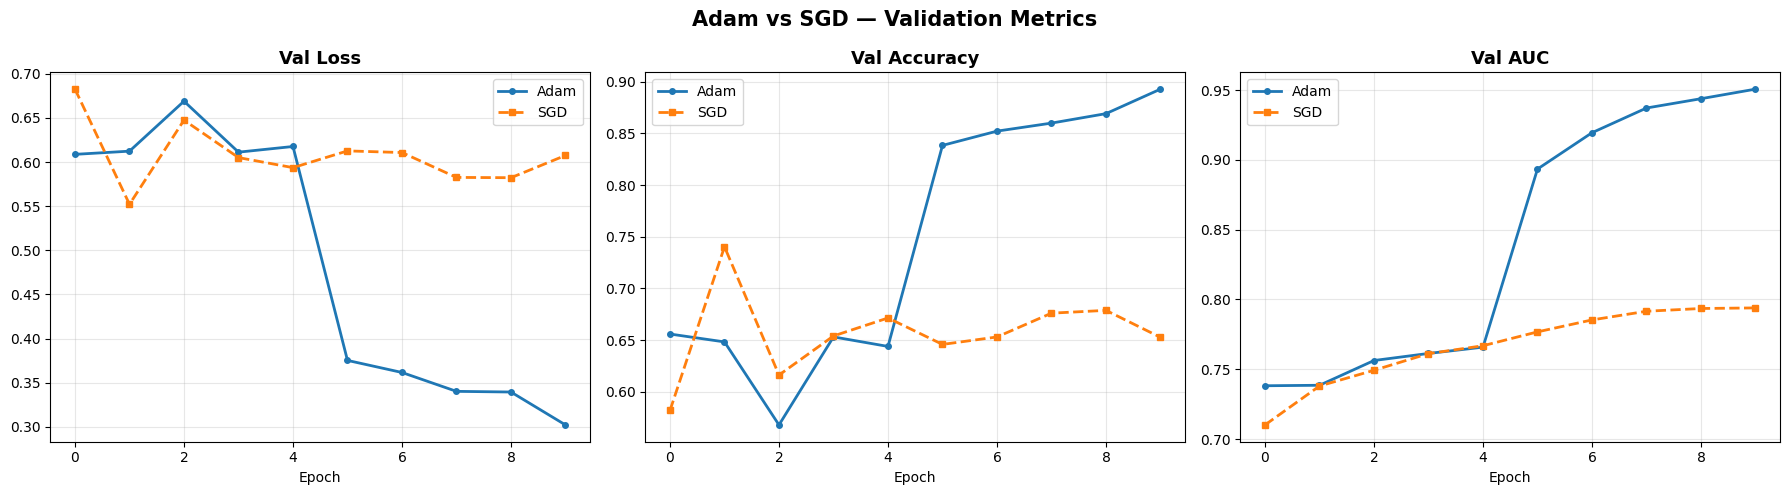

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics   = [('val_loss', 'Val Loss'), ('val_acc', 'Val Accuracy'), ('val_auc', 'Val AUC')]

for ax, (key, title) in zip(axes, metrics):
    ax.plot(history_adam[key], label='Adam',  linewidth=2, marker='o', markersize=4)
    ax.plot(history_sgd [key], label='SGD',   linewidth=2, marker='s', markersize=4, linestyle='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Adam vs SGD — Validation Metrics', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

### Comparison of Optimizers

| Metric | Adam | SGD |
|------|------|------|
| Final Validation Accuracy | ~0.89 | ~0.66 |
| Final Validation AUC | ~0.95 | ~0.79 |
| Convergence Speed | Fast | Slow |
| Training Stability | High | Moderate |

**Key Insight**

Adam demonstrated significantly faster convergence and better performance within the limited **10-epoch training budget**. This makes it more suitable for scenarios with **restricted training time**.

In [20]:
print(f'Best Val AUC — Adam : {best_auc_adam:.4f}')
print(f'Best Val AUC — SGD  : {best_auc_sgd:.4f}')

if best_auc_adam >= best_auc_sgd:
    best_exp   = 'Adam'
    best_save  = EXP1_SAVE
    best_model = model_adam
else:
    best_exp   = 'SGD'
    best_save  = EXP2_SAVE
    best_model = model_sgd

# Reload best checkpoint weights
best_model.load_state_dict(torch.load(best_save, map_location=DEVICE))
print(f'\n→ Using {best_exp} model (AUC={max(best_auc_adam, best_auc_sgd):.4f})')

Best Val AUC — Adam : 0.9507
Best Val AUC — SGD  : 0.7940

→ Using Adam model (AUC=0.9507)


In [21]:
_, _, test_labels, test_probs = evaluate(best_model, test_loader, criterion, DEVICE)
test_preds = (test_probs >= 0.5).astype(int)

acc  = accuracy_score (test_labels, test_preds)
prec = precision_score(test_labels, test_preds)
rec  = recall_score   (test_labels, test_preds)
f1   = f1_score       (test_labels, test_preds)
auc  = roc_auc_score  (test_labels, test_probs)

print('='*50)
print('   Test Set Classification Metrics')
print('='*50)
print(f'  Accuracy  : {acc :.4f}  ({acc *100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec :.4f}')
print(f'  F1-Score  : {f1  :.4f}')
print(f'  AUC-ROC   : {auc :.4f}')
print('='*50)
print()
print('Classification Report:')
print(classification_report(test_labels, test_preds, target_names=['Real','Fake']))

   Test Set Classification Metrics
  Accuracy  : 0.8731  (87.31%)
  Precision : 0.9485
  Recall    : 0.8829
  F1-Score  : 0.9145
  AUC-ROC   : 0.9436

Classification Report:
              precision    recall  f1-score   support

        Real       0.68      0.84      0.75      2621
        Fake       0.95      0.88      0.91      8720

    accuracy                           0.87     11341
   macro avg       0.82      0.86      0.83     11341
weighted avg       0.89      0.87      0.88     11341



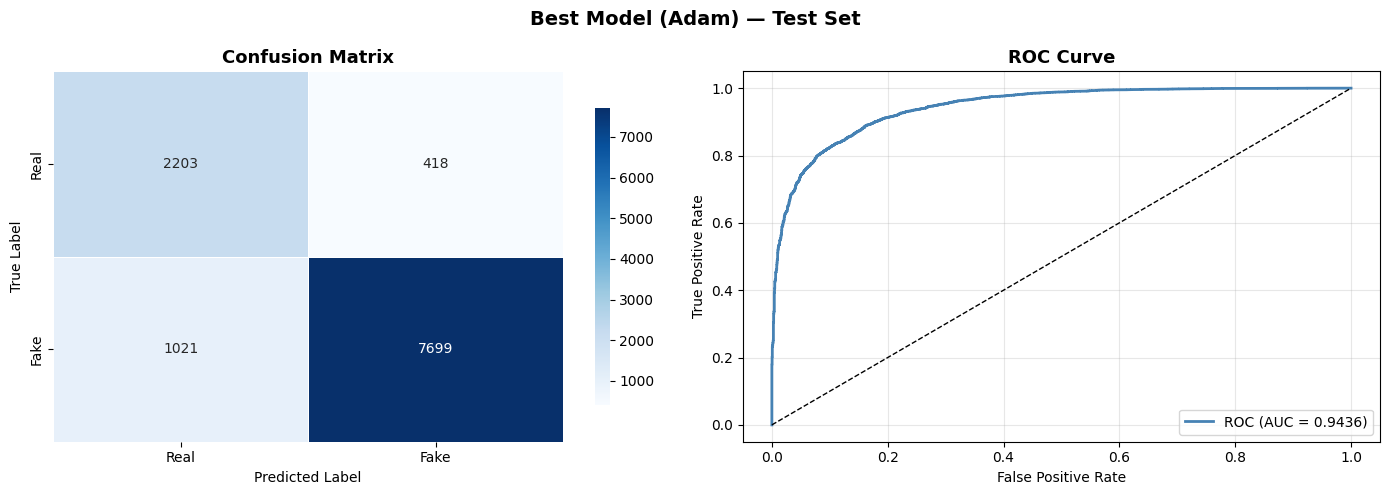

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'],
            linewidths=0.5, cbar_kws={'shrink':0.8})
ax1.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax1.set_ylabel('True Label'); ax1.set_xlabel('Predicted Label')

# ── ROC Curve ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(test_labels, test_probs)
ax2.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.4f})', color='steelblue')
ax2.plot([0,1],[0,1], 'k--', lw=1)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right'); ax2.grid(alpha=0.3)

plt.suptitle(f'Best Model ({best_exp}) — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [26]:
def test_metrics(model, save_path, name):
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    _, _, lbls, probs = evaluate(model, test_loader, criterion, DEVICE)
    preds = (probs >= 0.5).astype(int)
    return {
        'Optimizer' : name,
        'Accuracy'  : round(accuracy_score (lbls, preds), 4),
        'Precision' : round(precision_score(lbls, preds), 4),
        'Recall'    : round(recall_score   (lbls, preds), 4),
        'F1-Score'  : round(f1_score       (lbls, preds), 4),
        'AUC-ROC'   : round(roc_auc_score  (lbls, probs), 4),
    }

rows = [
    test_metrics(model_adam, EXP1_SAVE, 'Adam'),
    test_metrics(model_sgd,  EXP2_SAVE, 'SGD'),
]
df_cmp = pd.DataFrame(rows).set_index('Optimizer')
display(df_cmp.style.highlight_max(axis=0, color='lightgreen')
               .format('{:.4f}')
               .set_caption('Test Metrics — Green = Best'))

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Optimizer,,,,,
Adam,0.8731,0.9485,0.8829,0.9145,0.9436
SGD,0.6298,0.8953,0.5873,0.7093,0.7577


In [28]:
FINAL_SAVE = os.path.join(SAVE_DIR, f'resnet152_deepfake_final_{best_exp.lower()}.pth')

torch.save({
    'arch'         : 'resnet152',
    'best_exp'     : best_exp,
    'model_state'  : best_model.state_dict(),
    'num_classes'  : 2,
    'img_size'     : IMG_SIZE,
    'mean'         : MEAN,
    'std'          : STD,
    'test_metrics' : {
        'accuracy'  : acc,
        'precision' : prec,
        'recall'    : rec,
        'f1'        : f1,
        'auc'       : auc,
    },
}, FINAL_SAVE)

print(f'Model saved → {FINAL_SAVE}')
print(f'File size   : {os.path.getsize(FINAL_SAVE)/1e6:.1f} MB')

# Also save just weights (lighter)
WEIGHTS_SAVE = os.path.join(SAVE_DIR, f'resnet152_weights_{best_exp.lower()}.pth')
torch.save(best_model.state_dict(), WEIGHTS_SAVE)
print(f'Weights only saved → {WEIGHTS_SAVE}')

Model saved → /kaggle/working/resnet152_deepfake_final_adam.pth
File size   : 235.6 MB
Weights only saved → /kaggle/working/resnet152_weights_adam.pth


## Conclusion

Among the tested configurations, the **ResNet-152 model trained with the Adam optimizer** provided the best performance.  
The model achieved **87.31% accuracy and 0.94 AUC-ROC**, showing strong capability for **deepfake detection** even with limited training time and partial fine-tuning of the network.